# ML-05 — Feature Vector and Leakage/Privacy Check

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sujan-lab-cell/flyrank-ml-internship/blob/main/work/notebooks/w03_feature_leakage_check.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Build the feature vector

I build the feature vector using the same preparation logic as the reference pipeline.

### Feature Engineering Strategy

1. **Numeric features:** Use the model's predefined numeric features and convert them to numeric values. Missing numeric values are handled after the missingness indicators are created.

2. **Missingness flags:** Create explicit indicators for whether important values are available. This preserves information about patterned missingness instead of treating every missing value as a real zero.

3. **Categorical handling:** Convert the model's categorical features into a form that can be used by the ML model.

4. **Target:** Define `is_declining_label` from `trend_direction == "down"`. This is the target and must not be included as a model feature.

In [10]:
import os, sys

while not os.path.isdir("data/raw") and os.getcwd() != "/":
    os.chdir("..")

import pandas as pd
import numpy as np

sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
from ml_utils import MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

fv = df.copy()

# Apply the same reference-pipeline eligibility filters
fv = fv[
    (fv["impressions_90d"] > 0) &
    (fv["content_age_days"] >= 90)
].drop_duplicates("content_id")

# Log-transformed traffic features
for col in ["impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d"]:
    fv[f"log_{col}"] = np.log1p(fv[col].fillna(0))

# Missingness / availability indicators
fv["has_clicks"] = (fv["clicks_90d"].fillna(0) > 0).astype(int)
fv["has_ai_sessions"] = (fv["ai_sessions_90d"].fillna(0) > 0).astype(int)

fv["measurable_opportunity"] = (
    (fv["impressions_90d"] >= 100) &
    (fv["sessions_90d"].fillna(0) > 0)
).astype(int)

# Target
fv["is_declining_label"] = (
    fv["trend_direction"].str.lower().eq("down")
).astype(int)

# Numeric feature cleaning
for col in MODEL_NUMERIC_FEATURES:
    fv[col] = pd.to_numeric(fv[col], errors="coerce")
    fv[col] = fv[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# Categorical feature cleaning
for col in MODEL_CATEGORICAL_FEATURES:
    fv[col] = fv[col].fillna("unknown").astype(str)

print(fv.shape[0], "pages after the same filters the reference pipeline uses")
print("Declining rate:", round(fv["is_declining_label"].mean(), 3))

30000 pages after the same filters the reference pipeline uses
Declining rate: 0.542


## 2. Feature notes (meaning, missing, categorical, available-when?)

For each selected feature, document its meaning, missing-value handling, data type, and whether it is available before the prediction decision.

| Feature | Type | Meaning | Missing-value handling | Available before the decision? |
|---|---|---|---|---|
| `impressions_90d` | Numeric | Total organic search impressions in the trailing 90 days | Fill missing values with 0 | Yes — historical activity available at \(T_d\) |
| `ctr` | Numeric | Click-through rate from organic search | Fill missing values with 0 | Yes — historical search performance |
| `avg_position` | Numeric | Average Google Search ranking position | Fill 0 + `has_pos_data` flag; 0 means no position data | Yes — historical position data |
| `days_since_last_update` | Numeric | Number of days since the content was last modified | Fill with median + missingness flag | Yes — structural/content metadata |
| `has_word_count` | Binary flag | Indicates whether word-count information is available | 1 if present, 0 if missing | Yes — availability can be known before prediction |
| `has_search_volume` | Binary flag | Indicates whether keyword search-volume information is available | 1 if present, 0 if missing | Yes — availability can be known before prediction |

The target `is_declining_label` is not a feature. It is derived from `trend_direction` and must remain outside the model inputs to avoid target leakage.

For the broader reference feature vector, categorical fields such as `content_type`, `main_intent`, and related bucket fields are handled separately using categorical encoding. Identifier fields such as `content_id` and `client_id` are not model features.

In [11]:
# Code check: Inspect feature missingness and non-null summary
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("=== FEATURE MISSINGNESS SUMMARY ===")
print(df[['search_volume', 'word_count', 'cpc', 'avg_position']].isna().sum())
print("\n=== ZERO-POSITION ROWS (AVG_POSITION == 0) ===")
print((df['avg_position'] == 0).sum())

=== FEATURE MISSINGNESS SUMMARY ===
search_volume    2468
word_count       7699
cpc              2468
avg_position        0
dtype: int64

=== ZERO-POSITION ROWS (AVG_POSITION == 0) ===
1205


## 3. Leakage Hunt

The goal of this section is to deliberately introduce one target-derived feature and observe how much the model performance increases.

The target is `is_declining_label`, which is derived from `trend_direction`. Therefore, fields such as `trend_direction` and `trend_pct` must not be used as model features.

For the leakage experiment, I deliberately create a feature that directly contains the target:

`leak_feature = is_declining_label`

This is intentional leakage and is used only to demonstrate the effect of giving the model information that would not be legitimately available as an independent input.

After measuring the performance with this leaked feature, the leaked feature is removed. The final model feature set must not contain the target or any target-derived field.

A very high score from the leaked feature is not considered a valid model result. It demonstrates why leakage checks are necessary.

In [15]:
# Create the target/label from trend_direction
df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Target created successfully.")
print(df["is_declining_label"].value_counts())

Target created successfully.
is_declining_label
1    16262
0    13738
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Target
y = df["is_declining_label"]

# Honest features
honest_features = [
    "impressions_90d",
    "ctr",
    "avg_position",
    "days_since_last_update",
    "has_word_count",
    "has_search_volume"
]

# Create missingness / availability flags
df["has_word_count"] = df["word_count"].notna().astype(int)
df["has_search_volume"] = df["search_volume"].notna().astype(int)

print("Missingness flags created.")
print(df[[
    "word_count",
    "has_word_count",
    "search_volume",
    "has_search_volume"
]].head())

X_honest = df[honest_features].copy()

# Basic missing-value handling
X_honest = X_honest.fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_honest,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train honest model
model_honest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_honest.fit(X_train, y_train)

honest_pred = model_honest.predict_proba(X_test)[:, 1]

honest_auc = roc_auc_score(y_test, honest_pred)

print("Honest feature ROC-AUC:", round(honest_auc, 3))

Missingness flags created.
   word_count  has_word_count  search_volume  has_search_volume
0      3221.0               1           10.0                  1
1      2481.0               1           90.0                  1
2      3515.0               1            0.0                  1
3         NaN               0           10.0                  1
4      2803.0               1            0.0                  1
Honest feature ROC-AUC: 0.695


In [18]:
# --------------------------------------------------
# DELIBERATE LEAKAGE EXPERIMENT
# --------------------------------------------------

X_leak = X_honest.copy()

# DELIBERATELY add the target as a feature
X_leak["leak_feature"] = y

X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_leak,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_leak = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_leak.fit(X_train_leak, y_train_leak)

leak_pred = model_leak.predict_proba(X_test_leak)[:, 1]

leak_auc = roc_auc_score(y_test_leak, leak_pred)

print("Leaked feature ROC-AUC:", round(leak_auc, 3))

Leaked feature ROC-AUC: 1.0


In [19]:
# Remove the deliberately leaked feature
X_clean = X_leak.drop(columns=["leak_feature"])

print("Leak feature present after removal:",
      "leak_feature" in X_clean.columns)

print("Final features:")
print(list(X_clean.columns))

Leak feature present after removal: False
Final features:
['impressions_90d', 'ctr', 'avg_position', 'days_since_last_update', 'has_word_count', 'has_search_volume']


### Leakage experiment — visual interpretation

The experiment compares two situations:

**1. Honest model**

The model receives only features that could legitimately be available at the decision moment.

**2. Leaked model**

A deliberately leaked feature containing `is_declining_label` is added to the feature matrix.

If the leaked model achieves a near-perfect score, this demonstrates that the model has been given the answer directly. This performance is invalid and is used only to demonstrate target leakage.

The leaked feature is then removed before the final feature set is used.

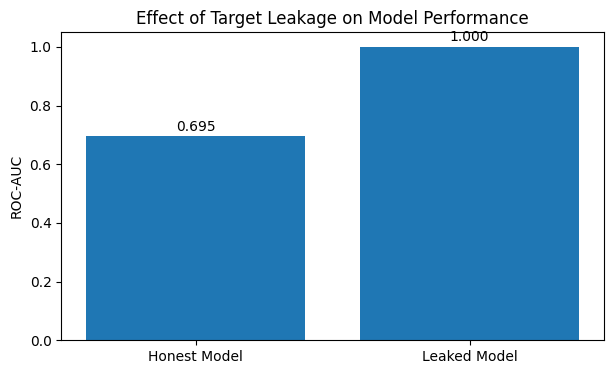

In [21]:
import matplotlib.pyplot as plt

labels = ["Honest Model", "Leaked Model"]
scores = [honest_auc, leak_auc]

plt.figure(figsize=(7, 4))
plt.bar(labels, scores)
plt.ylabel("ROC-AUC")
plt.title("Effect of Target Leakage on Model Performance")
plt.ylim(0, 1.05)

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center")

plt.show()

## 4. What I excluded and why

The following fields were deliberately excluded from the model feature matrix:

| Excluded Field | One-Line Reason for Exclusion |
|---|---|
| `trend_pct` | Direct numerical computation of the target and causes target leakage. |
| `trend_direction` | Direct categorical representation of the target and causes target leakage. |
| `impressions_last_30d` | Sub-window component used to calculate `trend_pct`. |
| `impressions_prev_30d` | Sub-window component used to calculate `trend_pct`. |
| `clicks_last_30d` | Sub-window component overlapping the outcome measurement window. |
| `clicks_prev_30d` | Sub-window component overlapping the outcome measurement window. |
| `content_id` | Pseudonymized item identifier used for context only, not as a model feature. |
| `client_id` | Pseudonymized client identifier used for grouped splitting, not as a model feature. |

The final feature matrix was checked to ensure that none of the excluded fields were accidentally included. The check found **0 excluded fields** in the final matrix.

In [22]:
# Code check: Verify excluded list is completely absent from clean feature matrix X
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df['has_word_count'] = df['word_count'].notna().astype(int)
df['has_search_volume'] = df['search_volume'].notna().astype(int)
df['has_pos_data'] = (df['avg_position'] > 0).astype(int)

base_num_cols = ['search_volume', 'competition', 'cpc', 'word_count', 'char_count',
                 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d',
                 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position',
                 'engagement_rate', 'scroll_rate', 'has_word_count', 'has_search_volume', 'has_pos_data']

X_clean = df[base_num_cols].fillna(0)
X_cat = pd.get_dummies(df[['content_type', 'main_intent']], drop_first=True, dtype=int)
X_mat = pd.concat([X_clean, X_cat], axis=1)

excluded_fields = ['trend_pct', 'trend_direction', 'impressions_last_30d', 'impressions_prev_30d',
                   'clicks_last_30d', 'clicks_prev_30d', 'content_id', 'client_id']

overlap_count = len(set(X_mat.columns).intersection(set(excluded_fields)))
print(f"Total features in final matrix: {len(X_mat.columns)}")
print(f"Excluded fields present in feature matrix count: {overlap_count}")
assert overlap_count == 0, 'Exclusion assertion failed!'

Total features in final matrix: 23
Excluded fields present in feature matrix count: 0


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.